In [1]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score, r2_score, precision_score, recall_score, f1_score, roc_auc_score, mean_absolute_error, mean_squared_error

In [2]:
# ---------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------
df = pd.read_csv("Task1_wildfire_weather_risk.csv")

df["year"] = pd.to_datetime(df["year_month"]).dt.year
panel_df = df[(df["year"] >= 2018) & (df["year"] <= 2021)].copy()

feature_cols = [
    "lat", "lon",
    "month_sin", "month_cos",
    "avg_tmax_c", "avg_tmin_c", "tot_prcp_mm"
]

train_df = panel_df[panel_df["year"] <= 2020].copy()
val_df   = panel_df[panel_df["year"] == 2021].copy()

X_train = train_df[feature_cols].values
y_train = train_df["kernel_risk_target"].values   # ★ 用 KDE risk 做 target

X_val = val_df[feature_cols].values
y_val = val_df["kernel_risk_target"].values

In [3]:
import xgboost as xgb

model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

# from sklearn.ensemble import RandomForestRegressor

# model = RandomForestRegressor(
#     n_estimators=300,
#     max_depth=None,
#     min_samples_split=2,
#     min_samples_leaf=1,
#     n_jobs=-1,
#     random_state=42
# )


# from sklearn.ensemble import ExtraTreesRegressor

# model = ExtraTreesRegressor(
#     n_estimators=300,
#     max_depth=None,
#     min_samples_split=2,
#     min_samples_leaf=1,
#     n_jobs=-1,
#     random_state=42
# )


# from sklearn.neural_network import MLPRegressor

# model = MLPRegressor(
#     hidden_layer_sizes=(64, 32),
#     activation="relu",
#     solver="adam",
#     max_iter=500,
#     random_state=42
# )

# from sklearn.linear_model import LinearRegression, Ridge, Lasso

# model = LinearRegression()
# model = Ridge(alpha=1.0)
# model = Lasso(alpha=0.001)


In [4]:
def risk_at_k_percent(risk, y_true, k):
    df_tmp = pd.DataFrame({"risk": risk, "y": y_true})
    df_tmp = df_tmp.sort_values("risk", ascending=False)
    top_k = max(int(len(df_tmp) * k), 1)
    captured = df_tmp.head(top_k)["y"].sum()
    total = df_tmp["y"].sum()
    return captured / total if total > 0 else 0

In [5]:
model.fit(X_train, y_train)
pred_val = model.predict(X_val)
# -----------------------------
# 回归指标（拟合 KDE）
# -----------------------------
print("R2 =", r2_score(y_val, pred_val))
print("MAE =", mean_absolute_error(y_val, pred_val))
print("MSE =", mean_squared_error(y_val, pred_val))

R2 = 0.989005154770527
MAE = 0.015452394918845773
MSE = 0.0005354291756231047


In [6]:
# -----------------------------
# 分类指标（对真实 has_fire）
# -----------------------------
risk_val = pred_val
y_val_fire = val_df["has_fire"].values

# 真实阳性比例
p = y_val_fire.mean()
print("prevalence =", p)

# 用同样比例的 top p% 作为预测阳性
threshold = np.quantile(risk_val, 1 - p)
pred_bin = (risk_val >= threshold).astype(int)

print("threshold =", threshold)

print("accuracy =", accuracy_score(y_val_fire, pred_bin))
print("precision =", precision_score(y_val_fire, pred_bin))
print("recall =", recall_score(y_val_fire, pred_bin))
print("f1 =", f1_score(y_val_fire, pred_bin))

# AUC（连续 risk vs has_fire）
print("AUC =", roc_auc_score(y_val_fire, risk_val))

# risk@k%（连续 risk）
print("risk@1% =", risk_at_k_percent(risk_val, y_val_fire, 0.01))
print("risk@3% =", risk_at_k_percent(risk_val, y_val_fire, 0.03))
print("risk@5% =", risk_at_k_percent(risk_val, y_val_fire, 0.05))

prevalence = 0.009416377426404422
threshold = 0.9069403879309026
accuracy = 0.9813600719886875
precision = 0.010238907849829351
recall = 0.010238907849829351
f1 = 0.010238907849829351
AUC = 0.6894713391079464
risk@1% = 0.010238907849829351
risk@3% = 0.08873720136518772
risk@5% = 0.1296928327645051


In [7]:
df_2023 = df[df["year"] == 2023].copy()
X_2023 = df_2023[feature_cols].values
risk_2023 = model.predict(X_2023)

df_2023["risk_pred"] = risk_2023
df_2023[["zip", "year_month", "has_fire", "kernel_risk_target", "risk_pred"]].head()

,zip,year_month,has_fire,kernel_risk_target,risk_pred
124705,92283,2023-03-01,1,0.031179,0.019223
124706,92283,2023-04-01,1,0.032940,0.027224
124707,92358,2023-04-01,1,0.155498,0.156336
124708,93514,2023-04-01,1,0.031750,0.011519
124709,92274,2023-05-01,1,0.150371,0.127721


In [8]:
auc = roc_auc_score(y_val_fire, risk_val)
print("AUC ROC =", auc)

AUC ROC = 0.6894713391079464


# 一口气跑多个model

In [9]:
# -----------------------------
# 定义所有模型（回归）
# -----------------------------
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "MLPRegressor": MLPRegressor(hidden_layer_sizes=(64,32), max_iter=500, random_state=42),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42),
    "ExtraTreesRegressor": ExtraTreesRegressor(n_estimators=300, n_jobs=-1, random_state=42),
    "SVR": SVR(kernel="rbf", C=1.0, gamma="scale"),
    "XGBRegressor": XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=42
    )
}

# -----------------------------
# 存结果的表
# -----------------------------
table_reg = []   # R2 / MAE / MSE
table_cls = []   # accuracy / precision / recall / F1 / AUC
table_risk = []  # risk@k%

# -----------------------------
# 真实标签（分类用）
# -----------------------------
y_val_fire = val_df["has_fire"].values
p = y_val_fire.mean()  # prevalence

In [10]:
# -----------------------------
# 依次跑所有模型
# -----------------------------
for name, model in models.items():
    print(f"\n==============================")
    print(f"Training model: {name}")
    print("==============================")

    # ---- fit ----
    model.fit(X_train, y_train)
    print(f"{name} fit complete")

    # ---- predict ----
    pred_val = model.predict(X_val)
    risk_val = pred_val

    # -----------------------------
    # 回归指标
    # -----------------------------
    r2 = r2_score(y_val, pred_val)
    mae = mean_absolute_error(y_val, pred_val)
    mse = mean_squared_error(y_val, pred_val)

    table_reg.append([name, r2, mae, mse])

    # -----------------------------
    # 分类指标（prevalence-matched）
    # -----------------------------
    threshold = np.quantile(risk_val, 1 - p)
    pred_bin = (risk_val >= threshold).astype(int)

    acc = accuracy_score(y_val_fire, pred_bin)
    prec = precision_score(y_val_fire, pred_bin, zero_division=0)
    rec = recall_score(y_val_fire, pred_bin, zero_division=0)
    f1 = f1_score(y_val_fire, pred_bin, zero_division=0)
    auc = roc_auc_score(y_val_fire, risk_val)

    table_cls.append([name, acc, prec, rec, f1, auc])

    # -----------------------------
    # risk@k%
    # -----------------------------
    r1 = risk_at_k_percent(risk_val, y_val_fire, 0.01)
    r3 = risk_at_k_percent(risk_val, y_val_fire, 0.03)
    r5 = risk_at_k_percent(risk_val, y_val_fire, 0.05)
    r10 = risk_at_k_percent(risk_val, y_val_fire, 0.10)
    r20 = risk_at_k_percent(risk_val, y_val_fire, 0.20)

    table_risk.append([name, r1, r3, r5, r10, r20])

    print(f"{name} risk@20% = {r20:.4f}")


Training model: LinearRegression
LinearRegression fit complete
LinearRegression risk@20% = 0.3857

Training model: Ridge
Ridge fit complete
Ridge risk@20% = 0.3857

Training model: Lasso
Lasso fit complete
Lasso risk@20% = 0.4061

Training model: MLPRegressor
MLPRegressor fit complete
MLPRegressor risk@20% = 0.4437

Training model: RandomForestRegressor
RandomForestRegressor fit complete
RandomForestRegressor risk@20% = 0.4437

Training model: ExtraTreesRegressor
ExtraTreesRegressor fit complete
ExtraTreesRegressor risk@20% = 0.4334

Training model: SVR
SVR fit complete
SVR risk@20% = 0.4164

Training model: XGBRegressor
XGBRegressor fit complete
XGBRegressor risk@20% = 0.4300


In [11]:
# -----------------------------
# 输出 3 张表
# -----------------------------
df_reg = pd.DataFrame(table_reg, columns=["Model", "R2", "MAE", "MSE"])
df_cls = pd.DataFrame(table_cls, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"])
df_risk = pd.DataFrame(table_risk, columns=["Model", "risk@1%", "risk@3%", "risk@5%", "risk@10%", "risk@20%"])

print("\n\n===== Table 1: Regression Metrics =====")
print(df_reg)

print("\n\n===== Table 2: Classification Metrics (Prevalence-Matched) =====")
print(df_cls)

print("\n\n===== Table 3: risk@k% Metrics =====")
print(df_risk)



===== Table 1: Regression Metrics =====
                   Model        R2       MAE       MSE
0       LinearRegression  0.693465  0.091278  0.014928
1                  Ridge  0.693465  0.091277  0.014928
2                  Lasso  0.691374  0.090499  0.015030
3           MLPRegressor  0.989150  0.016617  0.000528
4  RandomForestRegressor  0.990013  0.008200  0.000486
5    ExtraTreesRegressor  0.991678  0.011038  0.000405
6                    SVR  0.932858  0.045943  0.003270
7           XGBRegressor  0.989005  0.015452  0.000535


===== Table 2: Classification Metrics (Prevalence-Matched) =====
                   Model  Accuracy  Precision    Recall        F1       AUC
0       LinearRegression  0.981489   0.017065  0.017065  0.017065  0.683389
1                  Ridge  0.981489   0.017065  0.017065  0.017065  0.683394
2                  Lasso  0.981424   0.013652  0.013652  0.013652  0.683731
3           MLPRegressor  0.981296   0.006826  0.006826  0.006826  0.688466
4  RandomForestR

# Plot 2023 Risk

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt

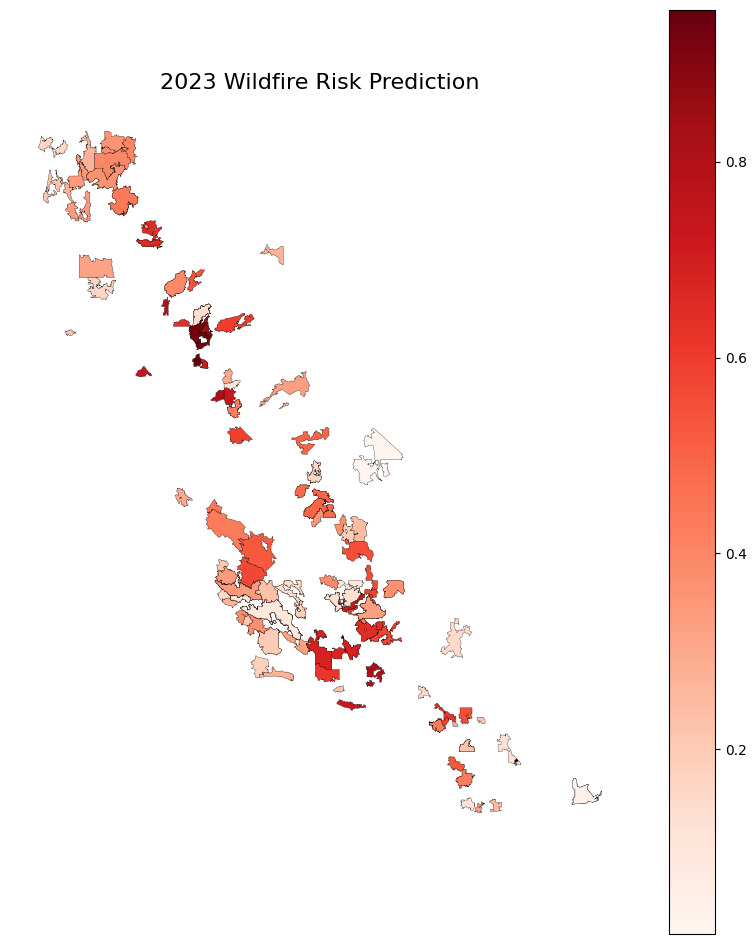

In [14]:
# -----------------------------
# 1. Load ZCTA shapefile (2023)
# -----------------------------
zcta = gpd.read_file(r".\tl_2023_us_zcta520\tl_2023_us_zcta520.shp")

# ZCTA 字段名是 ZCTA5CE20（字符串）
zcta["ZCTA5CE20"] = zcta["ZCTA5CE20"].astype(str)

# -----------------------------
# 2. 只保留 2023 出现过的 ZIP
# -----------------------------
df_2023["zip"] = df_2023["zip"].astype(str)

ca_zip = zcta[zcta["ZCTA5CE20"].isin(df_2023["zip"])].copy()

# -----------------------------
# 3. Merge risk_pred 到 shapefile
# -----------------------------
risk_map = ca_zip.merge(
    df_2023[["zip", "risk_pred"]],
    left_on="ZCTA5CE20",
    right_on="zip"
)

# -----------------------------
# 4. Plot choropleth
# -----------------------------
fig, ax = plt.subplots(1, 1, figsize=(10, 12))

risk_map.plot(
    column="risk_pred",
    cmap="Reds",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("2023 Wildfire Risk Prediction", fontsize=16)
ax.axis("off")

plt.savefig("2023_risk_map.png", dpi=300, bbox_inches="tight")
plt.show()